In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

path="/content/drive/MyDrive/dataPackage/"

orders = pd.read_csv(path+"orders.csv")
customers = pd.read_csv(path+"customers.csv")
web = pd.read_csv(path+"web_events_snapshot.csv")
support = pd.read_csv(path+"support_tickets.csv")
intervention = pd.read_csv(path+"intervention_history.csv")

Mounted at /content/drive


In [2]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

snapshot_date = pd.Timestamp("2025-09-30")

pre_snapshot = orders[
    orders['order_date'] <= snapshot_date
]

rfm = pre_snapshot.groupby('customer_id').agg({
    'order_date':'max',
    'order_id':'count',
    'gross_amount':'sum'
}).reset_index()

rfm.columns = [
    'customer_id',
    'last_order_date',
    'frequency',
    'monetary'
]

rfm['recency'] = (
    snapshot_date -
    rfm['last_order_date']
).dt.days

In [3]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

snapshot_date = pd.Timestamp("2025-09-30")

pre_snapshot = orders[
    orders['order_date'] <= snapshot_date
]

rfm = pre_snapshot.groupby('customer_id').agg({
    'order_date':'max',
    'order_id':'count',
    'gross_amount':'sum'
}).reset_index()

rfm.columns = [
    'customer_id',
    'last_order_date',
    'frequency',
    'monetary'
]

rfm['recency'] = (
    snapshot_date -
    rfm['last_order_date']
).dt.days

In [4]:
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [5]:
def assign_segment(row):

    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return "Champions"

    elif row['F_score'] >= 4:
        return "Loyal Customers"

    elif row['R_score'] <= 2:
        return "At Risk"

    elif row['recency'] > 120:
        return "Dormant"

    else:
        return "Potential Loyalists"

rfm['segment_name'] = rfm.apply(
    assign_segment,
    axis=1
)

In [9]:
ticket_features = support.groupby(
    'customer_id'
).size().reset_index(name='ticket_count')

web_features = web[
[
'customer_id',
'sessions_30d',
'campaign_clicks_30d'
]
]

rfm = rfm.merge(
    ticket_features,
    on='customer_id',
    how='left'
)

rfm = rfm.merge(
    web_features,
    on='customer_id',
    how='left'
)

rfm['ticket_count'] = rfm['ticket_count'].fillna(0)
rfm['sessions_30d'] = rfm['sessions_30d'].fillna(0)
rfm['campaign_clicks_30d'] = rfm['campaign_clicks_30d'].fillna(0)
rfm.head()
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            2400 non-null   object        
 1   last_order_date        2400 non-null   datetime64[ns]
 2   frequency              2400 non-null   int64         
 3   monetary               2400 non-null   float64       
 4   recency                2400 non-null   int64         
 5   R_score                2400 non-null   category      
 6   F_score                2400 non-null   category      
 7   M_score                2400 non-null   category      
 8   segment_name           2400 non-null   object        
 9   ticket_count_x         1247 non-null   float64       
 10  sessions_30d_x         2400 non-null   int64         
 11  campaign_clicks_30d_x  2400 non-null   int64         
 12  ticket_count_y         1247 non-null   float64       
 13  ses

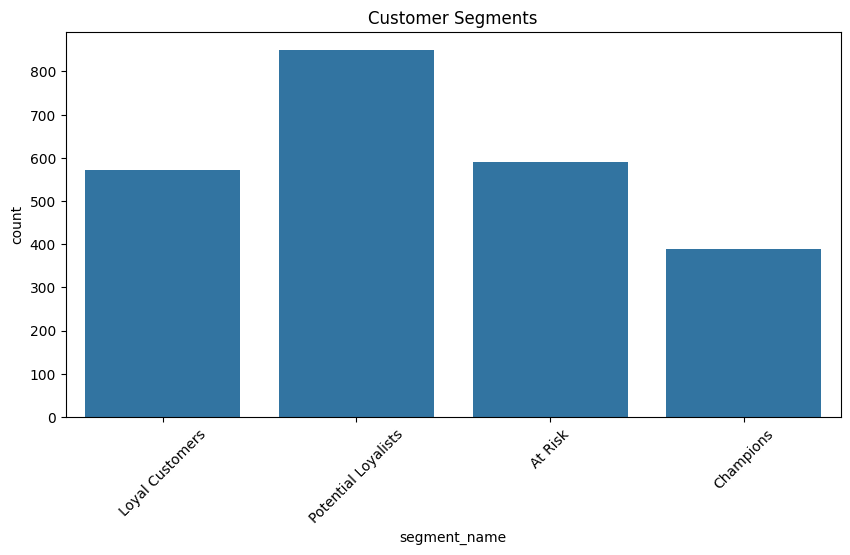

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x='segment_name'
)

plt.xticks(rotation=45)
plt.title("Customer Segments")
plt.show()

In [11]:
segments = rfm[
[
'customer_id',
'segment_name',
'recency',
'frequency',
'monetary',
'ticket_count',
'sessions_30d'
]
]

segments.to_csv(
    "segments.csv",
    index=False
)